Imports & Global Params

In [8]:
import duckdb
import numpy as np
import pandas as pd
import igraph as ig

import matplotlib.pyplot as plt
import seaborn as sns

import mord
import lightgbm as lgb

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from lightgbm import LGBMClassifier

np.random.seed(42)


Time Windows & Constants

In [9]:
graph_end_date = '2024-08-31'
block_window_start = '2024-09-01'
block_window_end   = '2024-09-30'

behavior_window_len = 30
min_blocks = 3

con = duckdb.connect()


Identify Heavy Blockers

In [10]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE heavy_blockers AS
SELECT did_id
FROM read_parquet('blocks.parquet')
WHERE created_date BETWEEN DATE '{block_window_start}' - INTERVAL 1 MONTH
                       AND DATE '{block_window_start}' - INTERVAL 1 DAY
GROUP BY did_id
HAVING COUNT(*) >= {min_blocks}
""")

num_blockers = con.execute(
    "SELECT COUNT(*) FROM heavy_blockers"
).fetchone()[0]

print(f"Number of heavy blockers: {num_blockers}")


Number of heavy blockers: 36343


Graph Construction

In [12]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE follow_edges AS
SELECT DISTINCT
    f.did_id AS src,
    f.subject_did_id AS dst
FROM read_parquet('follows.parquet') f
JOIN heavy_blockers b1 ON f.did_id = b1.did_id
JOIN heavy_blockers b2 ON f.subject_did_id = b2.did_id
WHERE f.created_date <= DATE '{graph_end_date}'
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE reply_edges AS
SELECT DISTINCT
    p.did_id AS src,
    p.reply_parent_did_id AS dst
FROM read_parquet('posts.parquet') p
JOIN heavy_blockers b1 ON p.did_id = b1.did_id
JOIN heavy_blockers b2 ON p.reply_parent_did_id = b2.did_id
WHERE p.reply_parent_did_id IS NOT NULL
  AND p.created_date <= DATE '{graph_end_date}'
""")

con.execute("""
CREATE OR REPLACE TEMP TABLE interaction_edges AS
SELECT src, dst FROM (
    SELECT src, dst FROM follow_edges
    UNION
    SELECT src, dst FROM reply_edges
)
WHERE src IS NOT NULL
  AND dst IS NOT NULL
  AND src != dst
""")

edges = con.execute("SELECT src, dst FROM interaction_edges").fetchdf()

g = ig.Graph.TupleList(
    edges.itertuples(index=False),
    directed=True
)

g.simplify(multiple=True, loops=True)
print(g.summary())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

IGRAPH DN-- 34786 3687734 -- 
+ attr: name (v)


Graph Features

In [13]:
g.vs["out_degree"] = g.outdegree()
g.vs["in_degree"]  = g.indegree()
g.vs["pagerank"]   = g.pagerank(directed=True)
g.vs["core"]       = g.coreness()

g_undirected = g.as_undirected()
g.vs["clustering"] = g_undirected.transitivity_local_undirected(mode="zero")

avg_deg = []
for v in g_undirected.vs:
    neighbors = v.neighbors()
    avg_deg.append(
        np.mean([n.degree() for n in neighbors]) if neighbors else 0
    )

g.vs["avg_neighbor_degree"] = avg_deg


In [14]:
graph_features = pd.DataFrame({
    "did_id": g.vs["name"],
    "out_degree": g.vs["out_degree"],
    "in_degree": g.vs["in_degree"],
    "pagerank": g.vs["pagerank"],
    "core": g.vs["core"],
    "clustering": g.vs["clustering"],
    "avg_neighbor_degree": g.vs["avg_neighbor_degree"]
})


Behavioral Features

In [15]:
con.execute(f"""
CREATE TEMP TABLE post_counts AS
SELECT did_id, COUNT(*) AS post_count
FROM read_parquet('posts.parquet')
WHERE created_date <= DATE '{graph_end_date}'
GROUP BY did_id
""")

con.execute(f"""
CREATE TEMP TABLE reply_counts AS
SELECT did_id, COUNT(*) AS reply_count
FROM read_parquet('posts.parquet')
WHERE reply_parent_did_id IS NOT NULL
  AND created_date <= DATE '{graph_end_date}'
GROUP BY did_id
""")

con.execute(f"""
CREATE TEMP TABLE like_counts AS
SELECT did_id, COUNT(*) AS like_count
FROM read_parquet('likes.parquet')
WHERE created_date <= DATE '{graph_end_date}'
GROUP BY did_id
""")

con.execute(f"""
CREATE TEMP TABLE repost_counts AS
SELECT did_id, COUNT(*) AS repost_count
FROM read_parquet('reposts.parquet')
WHERE created_date <= DATE '{graph_end_date}'
GROUP BY did_id
""")

behavior_df = con.execute("""
SELECT b.did_id,
       COALESCE(p.post_count,0) AS post_count,
       COALESCE(r.reply_count,0) AS reply_count,
       COALESCE(l.like_count,0) AS like_count,
       COALESCE(re.repost_count,0) AS repost_count
FROM heavy_blockers b
LEFT JOIN post_counts p ON b.did_id = p.did_id
LEFT JOIN reply_counts r ON b.did_id = r.did_id
LEFT JOIN like_counts l ON b.did_id = l.did_id
LEFT JOIN repost_counts re ON b.did_id = re.did_id
""").fetchdf()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Labels

In [16]:
label_df = con.execute(f"""
SELECT did_id, COUNT(*) AS future_blocks
FROM read_parquet('blocks.parquet')
WHERE created_date BETWEEN DATE '{block_window_start}'
                      AND DATE '{block_window_end}'
GROUP BY did_id
""").fetchdf()


Merging Tables

In [17]:
df = graph_features.merge(behavior_df, on="did_id", how="left")
df = df.merge(label_df, on="did_id", how="left")

df["future_blocks"] = df["future_blocks"].fillna(0)


Define Target

In [18]:
def block_class(x):
    if x <= 5:
        return 0
    elif x <= 15:
        return 1
    else:
        return 2

df["block_class"] = df["future_blocks"].apply(block_class)


Train/Validation split

In [19]:
FEATURE_BASE = [
    'out_degree','in_degree','pagerank','core',
    'clustering','avg_neighbor_degree',
    'post_count','reply_count','like_count','repost_count'
]

X = df[FEATURE_BASE]
y = df["block_class"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


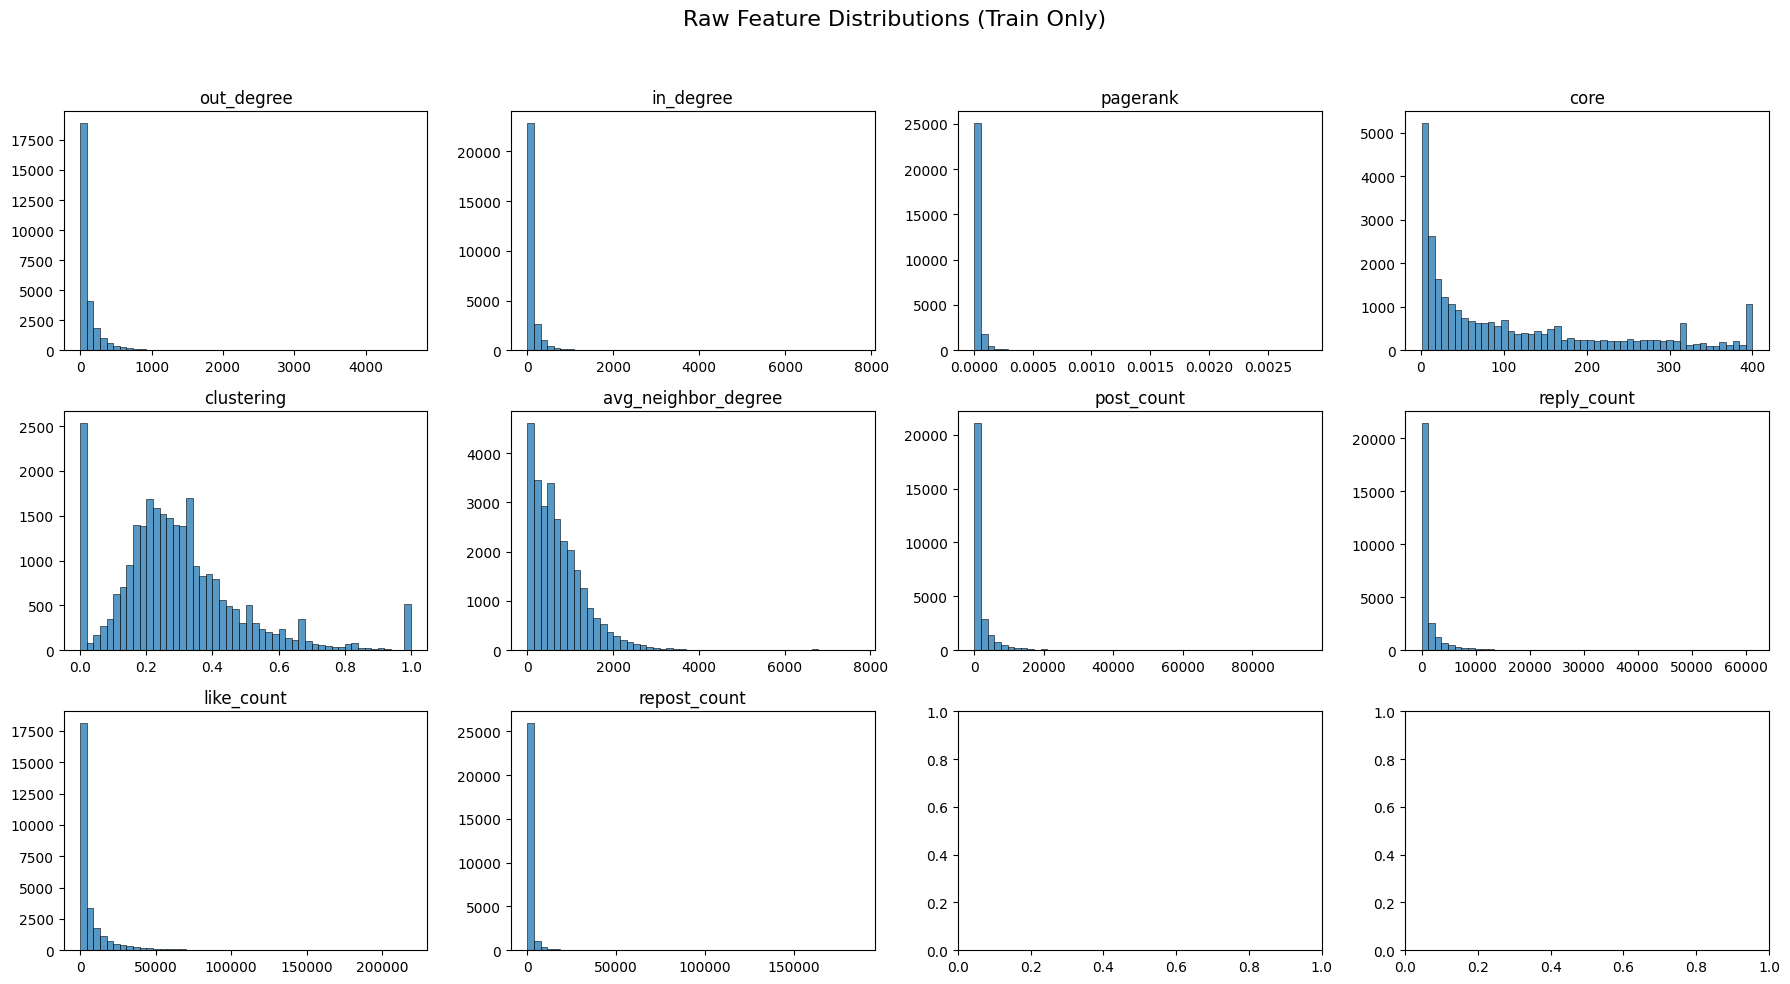

In [20]:
RAW_FEATURES = [
    'out_degree','in_degree','pagerank','core',
    'clustering','avg_neighbor_degree',
    'post_count','reply_count','like_count','repost_count'
]

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, RAW_FEATURES):
    sns.histplot(X_train[col], bins=50, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle("Raw Feature Distributions (Train Only)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Feature engineering on train data only

In [21]:
def engineer_features(df):
    df = df.copy()

    df["posts_per_day"]   = df["post_count"] / behavior_window_len
    df["replies_per_day"] = df["reply_count"] / behavior_window_len

    df["reply_ratio"]  = df["reply_count"]  / (df["post_count"] + 5)
    df["like_ratio"]   = df["like_count"]   / (df["post_count"] + 5)
    df["repost_ratio"] = df["repost_count"] / (df["post_count"] + 5)

    df["in_out_ratio"] = df["in_degree"] / (df["out_degree"] + 1)

    LOG_COLS = [
        'out_degree','in_degree','avg_neighbor_degree',
        'post_count','reply_count','like_count','repost_count',
        'posts_per_day','replies_per_day'
    ]

    for c in LOG_COLS:
        df[c] = np.log1p(df[c])

    return df


In [22]:
X_train = engineer_features(X_train)
X_val   = engineer_features(X_val)


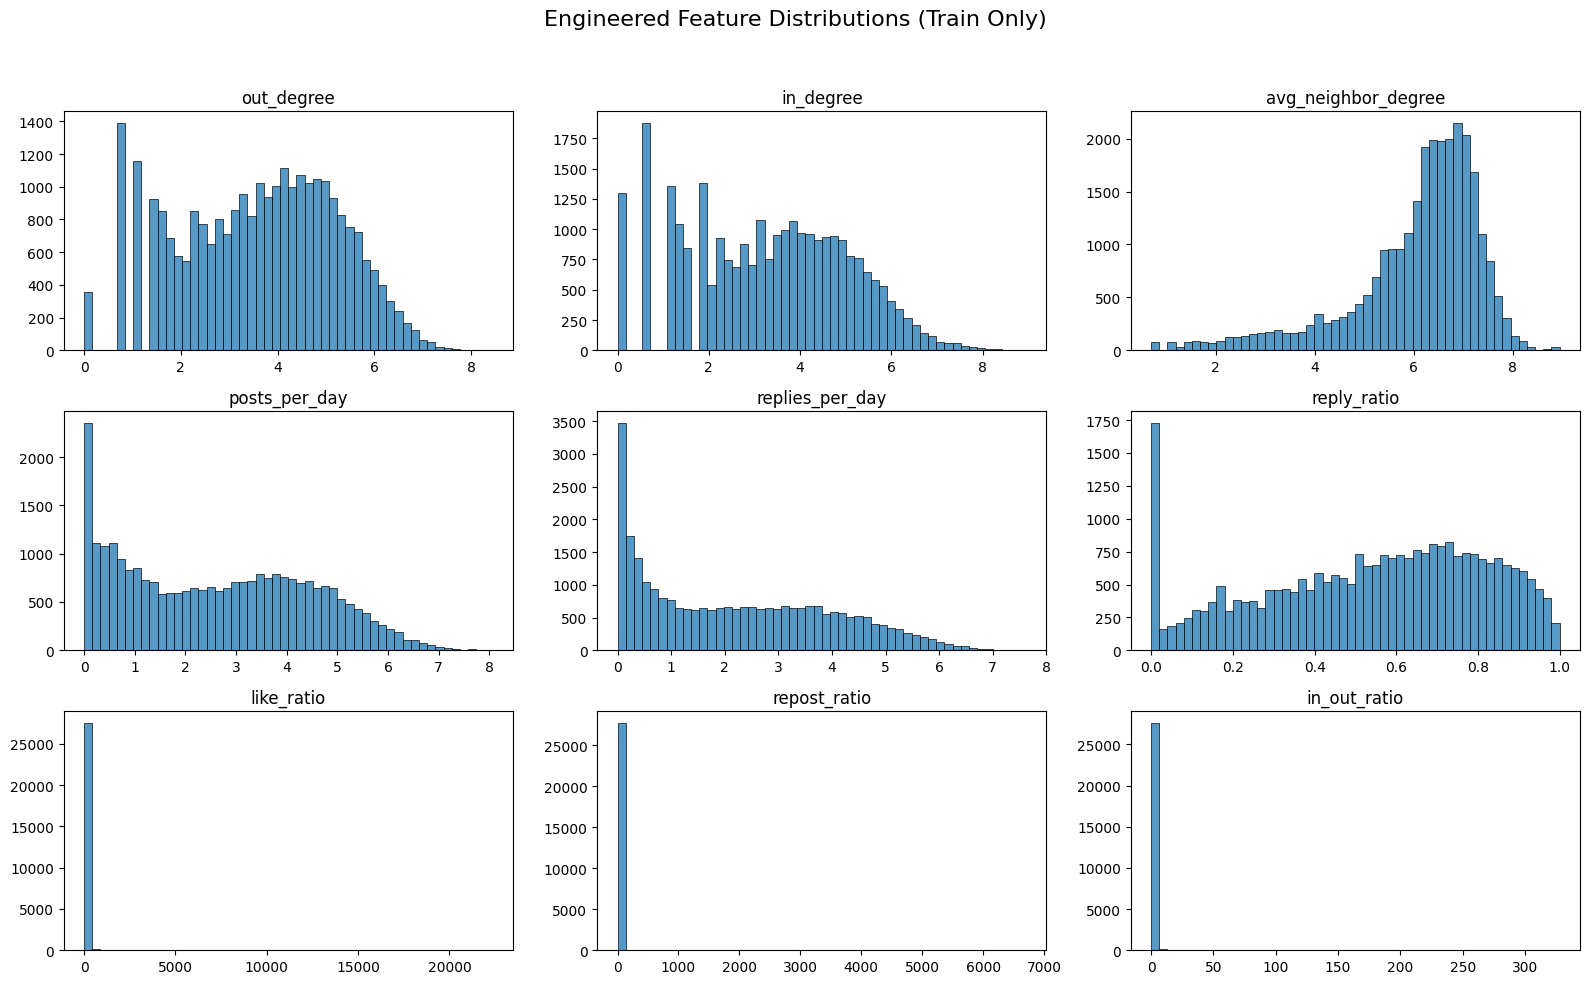

In [23]:
ENGINEERED_FEATURES = [
    'out_degree','in_degree','avg_neighbor_degree',
    'posts_per_day','replies_per_day',
    'reply_ratio','like_ratio','repost_ratio',
    'in_out_ratio'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, ENGINEERED_FEATURES):
    sns.histplot(X_train[col], bins=50, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle("Engineered Feature Distributions (Train Only)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


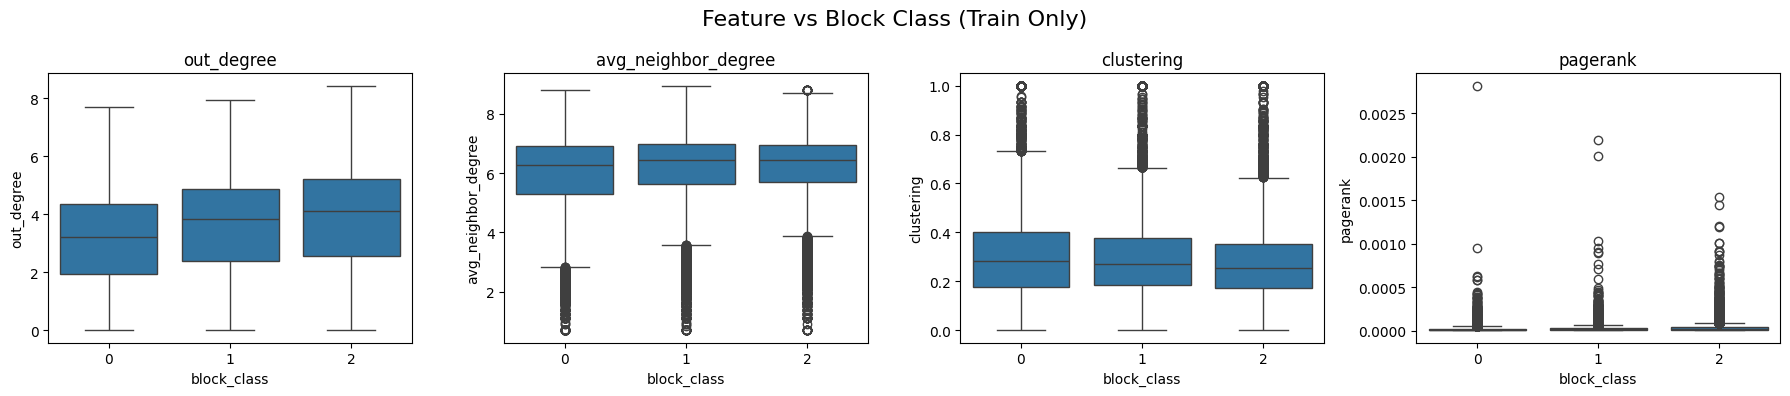

In [24]:
tmp = X_train.copy()
tmp["block_class"] = y_train.values

FEATURES_TO_CHECK = [
    'out_degree','avg_neighbor_degree','clustering','pagerank'
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, FEATURES_TO_CHECK):
    sns.boxplot(x="block_class", y=col, data=tmp, ax=ax)
    ax.set_title(col)

plt.suptitle("Feature vs Block Class (Train Only)", fontsize=16)
plt.tight_layout()
plt.show()


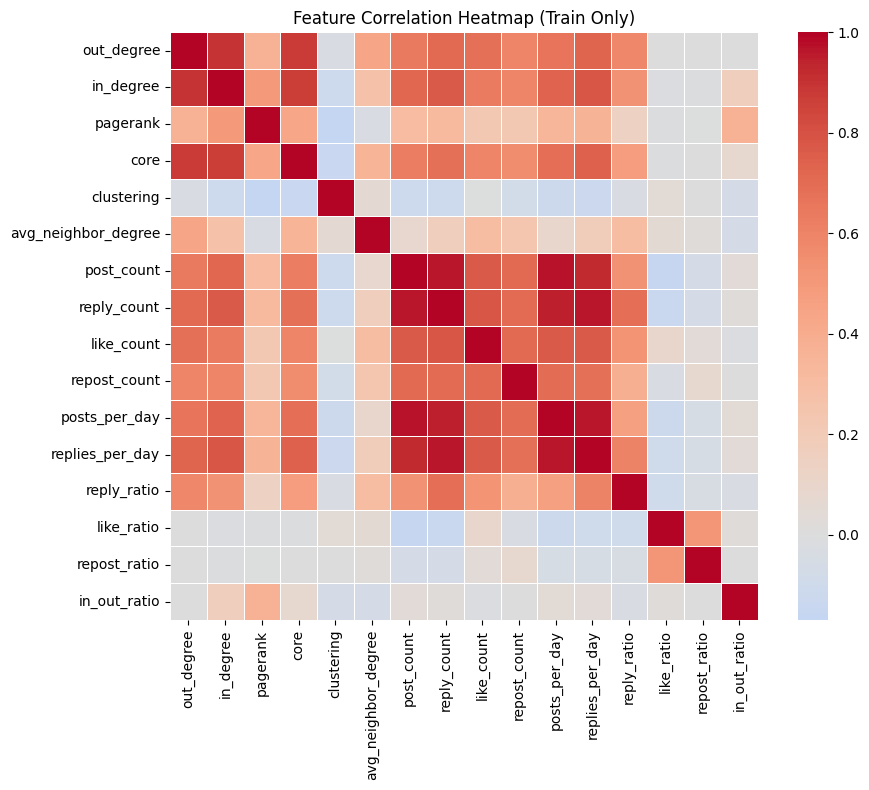

In [25]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    X_train.corr(),
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap (Train Only)")
plt.tight_layout()
plt.show()


In [26]:
corr = X_train.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [c for c in upper.columns if any(upper[c] > 0.85)]
print("Dropped:", to_drop)

X_train = X_train.drop(columns=to_drop)
X_val   = X_val.drop(columns=to_drop)


Dropped: ['in_degree', 'core', 'reply_count', 'posts_per_day', 'replies_per_day']


Standardization for ordinal model only

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)


In [28]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Low", "Medium", "High"],
        yticklabels=["Low", "Medium", "High"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()


Model 1 : Logistic regression

In [29]:
ord_model = mord.LogisticAT(alpha=1.0)
ord_model.fit(X_train_scaled, y_train)

y_pred_ord = ord_model.predict(X_val_scaled)
print(classification_report(y_val, y_pred_ord))


              precision    recall  f1-score   support

           0       0.57      0.10      0.17      2395
           1       0.28      0.85      0.42      1956
           2       0.55      0.13      0.21      2607

    accuracy                           0.32      6958
   macro avg       0.47      0.36      0.26      6958
weighted avg       0.48      0.32      0.25      6958



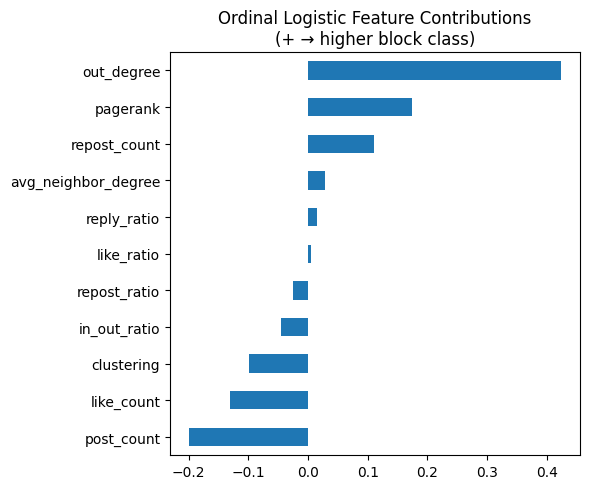

In [30]:
coef = pd.Series(
    ord_model.coef_.ravel(),
    index=X_train.columns
).sort_values()

plt.figure(figsize=(6, 5))
coef.plot(kind="barh")
plt.title("Ordinal Logistic Feature Contributions\n(+ → higher block class)")
plt.tight_layout()
plt.show()


Model 2

In [31]:
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=12,
    min_samples_leaf=30,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)
print(classification_report(y_val, y_pred_rf))


              precision    recall  f1-score   support

           0       0.48      0.55      0.51      2395
           1       0.36      0.30      0.33      1956
           2       0.52      0.52      0.52      2607

    accuracy                           0.47      6958
   macro avg       0.45      0.45      0.45      6958
weighted avg       0.46      0.47      0.46      6958



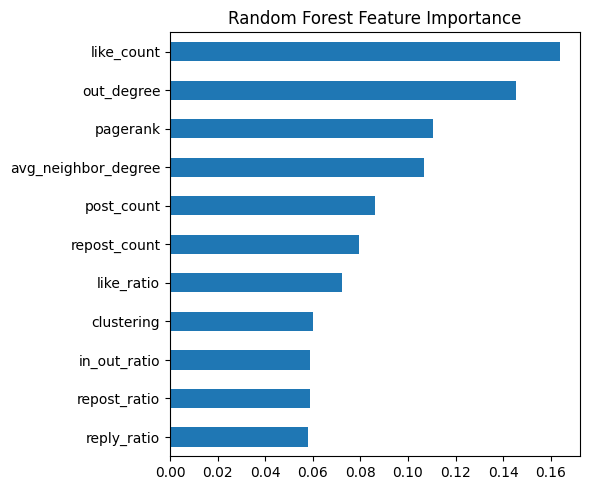

In [32]:
rf_imp = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values()

plt.figure(figsize=(6, 5))
rf_imp.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()


In [33]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
cw = dict(enumerate(class_weights))

lgbm = LGBMClassifier(
    objective="multiclassova",
    num_class=3,
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight=cw,
    random_state=42
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="multi_logloss",
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

y_pred_lgbm = lgbm.predict(X_val)
print(classification_report(y_val, y_pred_lgbm))


[LightGBM] [Info] Number of positive: 9577, number of negative: 18251
[LightGBM] [Info] Number of positive: 7825, number of negative: 20003
[LightGBM] [Info] Number of positive: 10426, number of negative: 17402
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001033 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 27828, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147
              precision    recall 

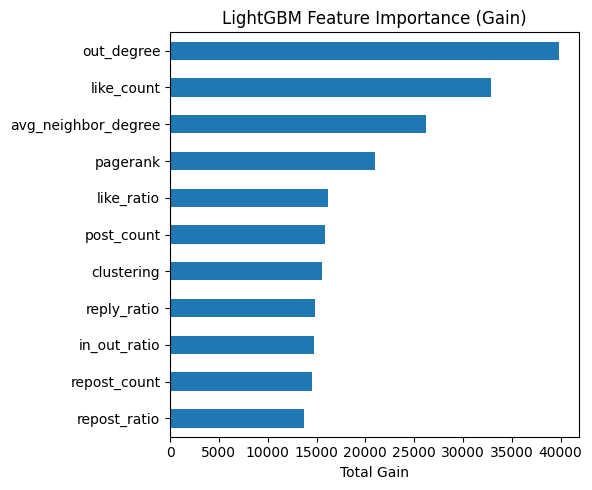

In [34]:
lgb_imp = pd.Series(
    lgbm.booster_.feature_importance(importance_type="gain"),
    index=X_train.columns
).sort_values()

plt.figure(figsize=(6, 5))
lgb_imp.plot(kind="barh")
plt.title("LightGBM Feature Importance (Gain)")
plt.xlabel("Total Gain")
plt.tight_layout()
plt.show()


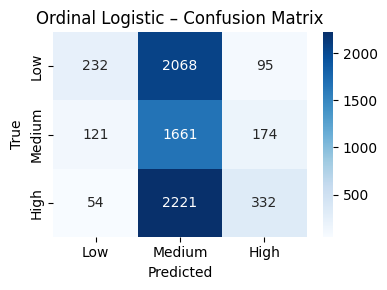

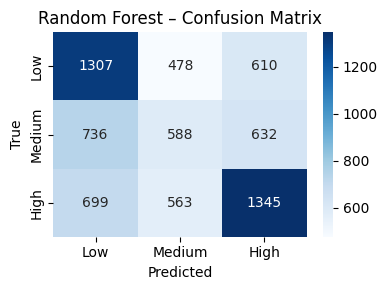

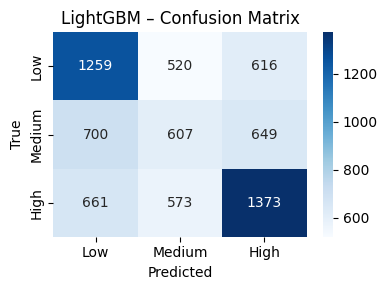

In [35]:
plot_confusion(y_val, y_pred_ord, "Ordinal Logistic – Confusion Matrix")
plot_confusion(y_val, y_pred_rf,  "Random Forest – Confusion Matrix")
plot_confusion(y_val, y_pred_lgbm,"LightGBM – Confusion Matrix")


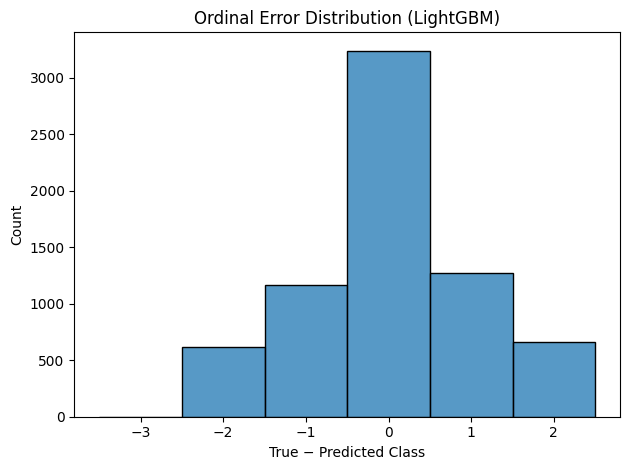

In [36]:
errors = y_val - y_pred_lgbm
sns.histplot(errors, bins=np.arange(-3,4)-0.5)
plt.title("Ordinal Error Distribution (LightGBM)")
plt.xlabel("True − Predicted Class")
plt.tight_layout()
plt.show()


In [37]:
def metrics(y_true, y_pred):
    return {
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "Recall High": recall_score(y_true, y_pred, average=None)[2],
        "Precision High": precision_score(y_true, y_pred, average=None)[2],
        "Ordinal Error": np.mean(np.abs(y_true - y_pred))
    }

pd.DataFrame.from_dict({
    "Ordinal Logistic": metrics(y_val, y_pred_ord),
    "Random Forest": metrics(y_val, y_pred_rf),
    "LightGBM": metrics(y_val, y_pred_lgbm)
}, orient="index")


,Macro F1,Recall High,Precision High,Ordinal Error
Ordinal Logistic,0.264255,0.127349,0.552413,0.701638
Random Forest,0.451599,0.515919,0.519907,0.722478
LightGBM,0.452566,0.526659,0.520470,0.718022


Behavioural vs Graph only 

In [49]:
GRAPH_FEATURES = [
    'out_degree',
    'pagerank',
    'clustering',
    'avg_neighbor_degree',
    'in_out_ratio'
]

BEHAVIOR_FEATURES = [
    'reply_ratio',
    'like_ratio',
    'repost_ratio'
]

print("Graph features:", GRAPH_FEATURES)
print("Behavior features:", BEHAVIOR_FEATURES)


Graph features: ['out_degree', 'pagerank', 'clustering', 'avg_neighbor_degree', 'in_out_ratio']
Behavior features: ['reply_ratio', 'like_ratio', 'repost_ratio']


In [43]:
missing_graph = set(GRAPH_FEATURES) - set(X_train.columns)
missing_behavior = set(BEHAVIOR_FEATURES) - set(X_train.columns)

print("Missing graph features:", missing_graph)
print("Missing behavior features:", missing_behavior)


Missing graph features: {'core', 'in_degree'}
Missing behavior features: set()


In [44]:
rf_params = dict(
    n_estimators=600,
    max_depth=12,
    min_samples_leaf=30,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


In [45]:
rf_behavior = RandomForestClassifier(**rf_params)

rf_behavior.fit(
    X_train[BEHAVIOR_FEATURES],
    y_train
)

y_pred_behavior = rf_behavior.predict(
    X_val[BEHAVIOR_FEATURES]
)

print("Random Forest — BEHAVIOR ONLY")
print(classification_report(y_val, y_pred_behavior))


Random Forest — BEHAVIOR ONLY
              precision    recall  f1-score   support

           0       0.40      0.44      0.42      2395
           1       0.30      0.26      0.28      1956
           2       0.42      0.43      0.42      2607

    accuracy                           0.38      6958
   macro avg       0.37      0.37      0.37      6958
weighted avg       0.38      0.38      0.38      6958



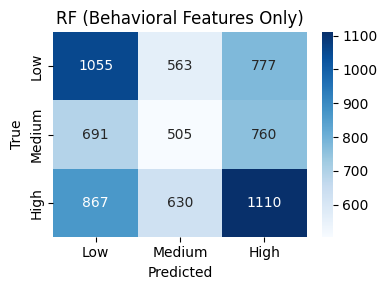

In [46]:
plot_confusion(
    y_val,
    y_pred_behavior,
    "RF (Behavioral Features Only)"
)


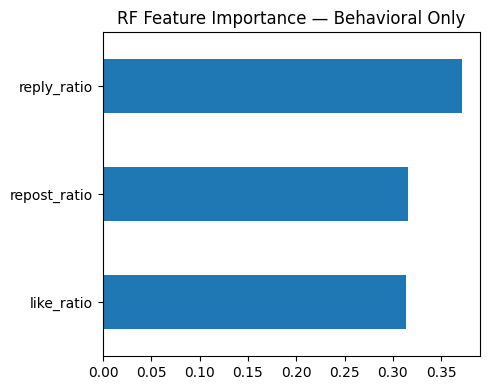

In [47]:
behavior_imp = pd.Series(
    rf_behavior.feature_importances_,
    index=BEHAVIOR_FEATURES
).sort_values()

plt.figure(figsize=(5, 4))
behavior_imp.plot(kind="barh")
plt.title("RF Feature Importance — Behavioral Only")
plt.tight_layout()
plt.show()


In [50]:
rf_graph = RandomForestClassifier(**rf_params)

rf_graph.fit(
    X_train[GRAPH_FEATURES],
    y_train
)

y_pred_graph = rf_graph.predict(
    X_val[GRAPH_FEATURES]
)

print("Random Forest — GRAPH ONLY")
print(classification_report(y_val, y_pred_graph))


Random Forest — GRAPH ONLY
              precision    recall  f1-score   support

           0       0.46      0.60      0.52      2395
           1       0.34      0.29      0.31      1956
           2       0.51      0.42      0.46      2607

    accuracy                           0.44      6958
   macro avg       0.43      0.44      0.43      6958
weighted avg       0.44      0.44      0.44      6958



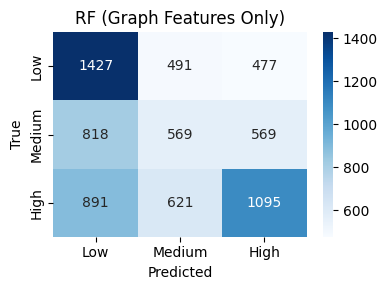

In [51]:
plot_confusion(
    y_val,
    y_pred_graph,
    "RF (Graph Features Only)"
)


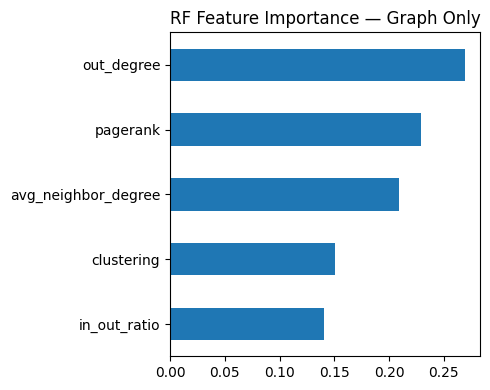

In [52]:
graph_imp = pd.Series(
    rf_graph.feature_importances_,
    index=GRAPH_FEATURES
).sort_values()

plt.figure(figsize=(5, 4))
graph_imp.plot(kind="barh")
plt.title("RF Feature Importance — Graph Only")
plt.tight_layout()
plt.show()


In [53]:
def rf_metrics(y_true, y_pred):
    return {
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "Recall High": recall_score(y_true, y_pred, average=None)[2],
        "Precision High": precision_score(y_true, y_pred, average=None)[2],
        "Ordinal Error": np.mean(np.abs(y_true - y_pred))
    }

comparison = pd.DataFrame.from_dict({
    "Behavior Only": rf_metrics(y_val, y_pred_behavior),
    "Graph Only": rf_metrics(y_val, y_pred_graph),
}, orient="index")

comparison


,Macro F1,Recall High,Precision High,Ordinal Error
Behavior Only,0.373424,0.425777,0.419343,0.852544
Graph Only,0.430048,0.420023,0.511443,0.752371


In [ ]:
comparison.loc["Graph + Behavior"] = rf_metrics(
    y_val,
    y_pred_rf   
)

comparison


,Macro F1,Recall High,Precision High,Ordinal Error
Behavior Only,0.373424,0.425777,0.419343,0.852544
Graph Only,0.430048,0.420023,0.511443,0.752371
Graph + Behavior,0.451599,0.515919,0.519907,0.722478
